# Pueblo Bonito LiDAR Proof of Concept

**Goal:** validate the core pipeline before the North Carolina build.

1. Pull 1m elevation data (USGS 3DEP — same program as the 2016 Chaco collection on OpenTopography) for a small AOI around Pueblo Bonito.
2. Generate Weiner-style hillshades at multiple sun azimuths/altitudes (the "manipulable light source" technique from Friedman/Sofaer/Weiner).
3. Add slope + a multidirectional composite to make sunken linear features (roads) pop.
4. Eyeball known roads — e.g. the segments running north from Pueblo Bonito toward Pueblo Alto, and the Jackson Stairway area.

This is deliberately **not** machine learning. It answers one question: *can I pull the data and see his roads doing what he's doing?*

The same ingest → derivative → visualize skeleton gets reused for the North Carolina elevation-threshold project (swap the analysis step, keep the skeleton).

**Setup**
```
pip install requests rasterio numpy matplotlib python-dotenv
```
Get a free OpenTopography API key at https://portal.opentopography.org (Account → myOpenTopo → Request API key), then put it in a `.env` file next to this notebook:
```
OPENTOPO_API_KEY=yourkeyhere
```
Keep `.env` in `.gitignore` so the key never hits the repo.

## 1 · Imports & configuration

In [13]:
import os
from pathlib import Path

import numpy as np
import requests
import rasterio
import matplotlib.pyplot as plt
from dotenv import load_dotenv

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [14]:
# --- Config -----------------------------------------------------------

# Reads OPENTOPO_API_KEY from a .env file in this directory (or any parent).
# .env should contain one line:  OPENTOPO_API_KEY=yourkeyhere
load_dotenv()
API_KEY = os.environ.get("OPENTOPO_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "OPENTOPO_API_KEY not found. Create a .env file next to this "
        "notebook containing: OPENTOPO_API_KEY=yourkeyhere"
    )
print(f"[ok] API key loaded ({API_KEY[:4]}...{API_KEY[-4:]})")

# Small AOI centered on Pueblo Bonito / downtown Chaco (~36.0608 N, -107.9617 W).
# Big enough to catch road segments toward Pueblo Alto and the cliff-top
# stairways; small enough to download in seconds.
AOI = {
    "south": 36.035,
    "north": 36.090,
    "west": -108.000,
    "east": -107.910,
}

# USGS 3DEP 1m through OpenTopography's raster API.
# If USGS1m has no coverage for the AOI, the download cell falls back to USGS10m.
DATASET = "USGS1m"
OT_URL = "https://portal.opentopography.org/API/usgsdem"

OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Weiner-style light sweep: same terrain, multiple sun positions.
# Low sun angles (altitude 15-25°) are what make shallow road depressions visible.
HILLSHADE_PARAMS = [
    {"azimuth": 315, "altitude": 45},   # classic default (control)
    {"azimuth": 315, "altitude": 20},   # low NW sun
    {"azimuth": 45,  "altitude": 20},   # low NE sun
    {"azimuth": 135, "altitude": 20},   # low SE sun
    {"azimuth": 225, "altitude": 20},   # low SW sun
]

[ok] API key loaded (2d0d...2f7f)


## 2 · Download the DEM

One HTTP request to OpenTopography. The response is a GeoTIFF; if `USGS1m` has a coverage gap we retry with `USGS10m` (roads will be fainter at 10m, but the pipeline still validates).

In [15]:
def download_dem(dest: Path, dataset: str = DATASET) -> Path:
    if dest.exists():
        print(f"[skip] DEM already downloaded: {dest}")
        return dest

    params = {
        "datasetName": dataset,
        "south": AOI["south"],
        "north": AOI["north"],
        "west": AOI["west"],
        "east": AOI["east"],
        "outputFormat": "GTiff",
        "API_Key": API_KEY,
    }
    print(f"[dl] Requesting {dataset} DEM from OpenTopography...")
    r = requests.get(OT_URL, params=params, timeout=300)
    if r.status_code != 200 or r.content[:4] not in (b"II*\x00", b"MM\x00*"):
        # Not a TIFF -> probably an error message or no coverage
        msg = r.text[:500]
        if dataset == "USGS1m":
            print(f"[warn] USGS1m failed ({r.status_code}): {msg}")
            print("[warn] Falling back to USGS10m...")
            return download_dem(dest, dataset="USGS10m")
        raise RuntimeError(f"Download failed ({r.status_code}): {msg}")
    dest.write_bytes(r.content)
    print(f"[ok] Saved {dest} ({len(r.content)/1e6:.1f} MB)")
    return dest


dem_path = download_dem(OUT_DIR / "pueblo_bonito_dem.tif")

[skip] DEM already downloaded: output\pueblo_bonito_dem.tif


## 3 · Load the raster & inspect

In [16]:
with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(np.float64)
    profile = src.profile
    xres, yres = src.res
    # Cell size in projected units; if the data comes back geographic,
    # approximate meters at this latitude.
    if src.crs and src.crs.is_geographic:
        lat = np.radians((AOI["north"] + AOI["south"]) / 2)
        xres = xres * 111_320 * np.cos(lat)
        yres = yres * 110_540

nodata = profile.get("nodata")
if nodata is not None:
    dem[dem == nodata] = np.nan

print(f"DEM shape: {dem.shape}, cell ~{xres:.2f}m x {yres:.2f}m")
print(f"Elevation range: {np.nanmin(dem):.1f} - {np.nanmax(dem):.1f} m")

DEM shape: (594, 972), cell ~8.33m x 10.24m
Elevation range: 1846.3 - 2041.0 m


### Elevation

This exact layer is what becomes the North Carolina threshold filter later — there it's just `dem > threshold_feet * 0.3048`.

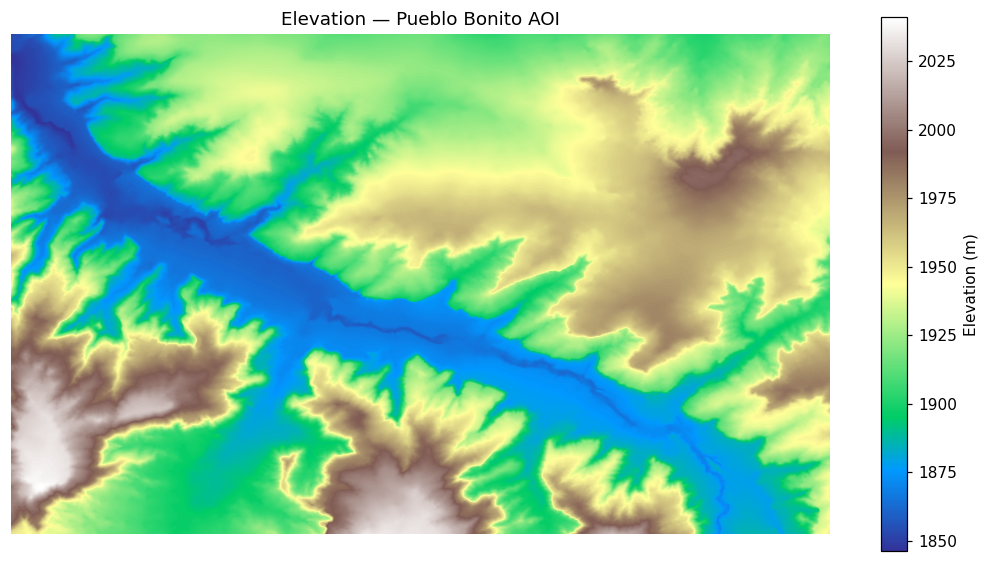

In [17]:
plt.figure(figsize=(12, 9))
plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (m)", shrink=0.7)
plt.title("Elevation — Pueblo Bonito AOI")
plt.axis("off")
plt.savefig(OUT_DIR / "elevation.png", dpi=200, bbox_inches="tight")
plt.show()

## 4 · Terrain derivatives (hillshade & slope)

In [18]:
def compute_gradients(dem, xres, yres):
    """Return dz/dx, dz/dy using real-world cell sizes."""
    dzdy, dzdx = np.gradient(dem, yres, xres)
    return dzdx, dzdy


def hillshade(dem, xres, yres, azimuth=315.0, altitude=45.0):
    """Standard Horn-style hillshade, values 0-255."""
    dzdx, dzdy = compute_gradients(dem, xres, yres)
    slope = np.pi / 2.0 - np.arctan(np.sqrt(dzdx**2 + dzdy**2))
    aspect = np.arctan2(-dzdx, dzdy)
    az = np.radians(360.0 - azimuth + 90.0)
    alt = np.radians(altitude)
    shaded = (np.sin(alt) * np.sin(slope)
              + np.cos(alt) * np.cos(slope) * np.cos(az - aspect))
    return (255 * (shaded + 1) / 2).astype(np.uint8)


def slope_degrees(dem, xres, yres):
    dzdx, dzdy = compute_gradients(dem, xres, yres)
    return np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))


def save_geotiff(path, arr, profile):
    prof = profile.copy()
    prof.update(count=1, dtype=str(arr.dtype), compress="lzw")
    # The source DEM's nodata (e.g. -999999.0) is invalid for derivative
    # dtypes like uint8 — drop it; these layers have no nodata cells anyway.
    prof["nodata"] = None
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr, 1)

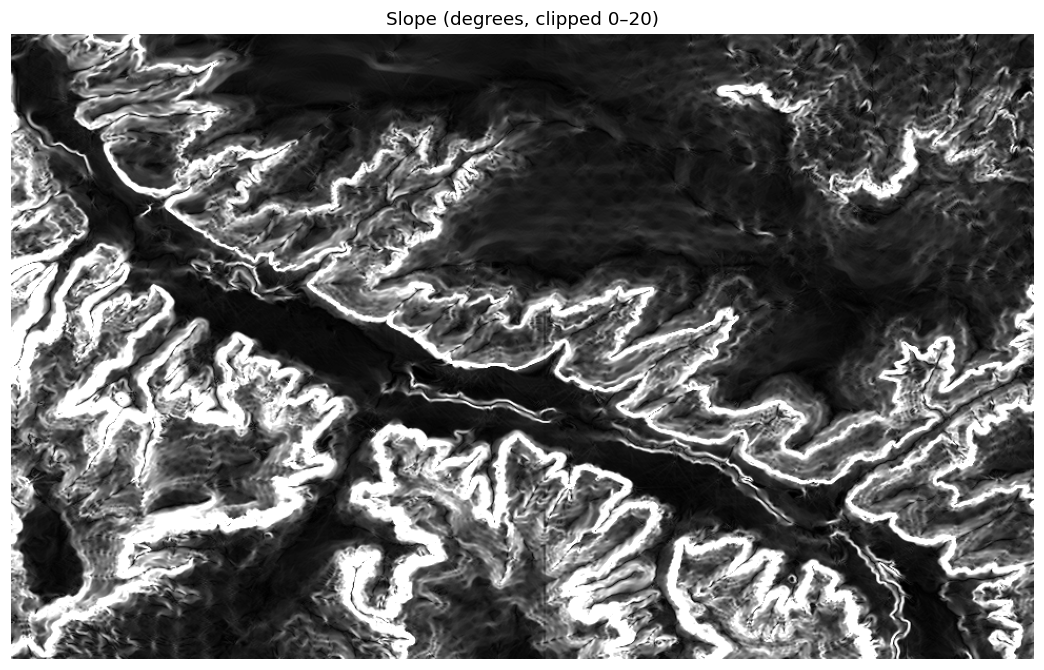

In [19]:
# Slope (clipped to 0-20° so gentle road-scale relief is visible)
dem_filled = np.nan_to_num(dem, nan=np.nanmean(dem))
slp = slope_degrees(dem_filled, xres, yres)
save_geotiff(OUT_DIR / "slope.tif", slp.astype(np.float32), profile)

plt.figure(figsize=(12, 9))
plt.imshow(np.clip(slp, 0, 20), cmap="gray")
plt.title("Slope (degrees, clipped 0–20)")
plt.axis("off")
plt.savefig(OUT_DIR / "slope.png", dpi=200, bbox_inches="tight")
plt.show()

## 5 · Weiner-style hillshade sweep

Same terrain, five sun positions. The manipulable light source is the whole trick: a road running roughly perpendicular to the light direction throws a visible shadow line; parallel to the light it disappears. Flip through these and watch features appear/vanish.

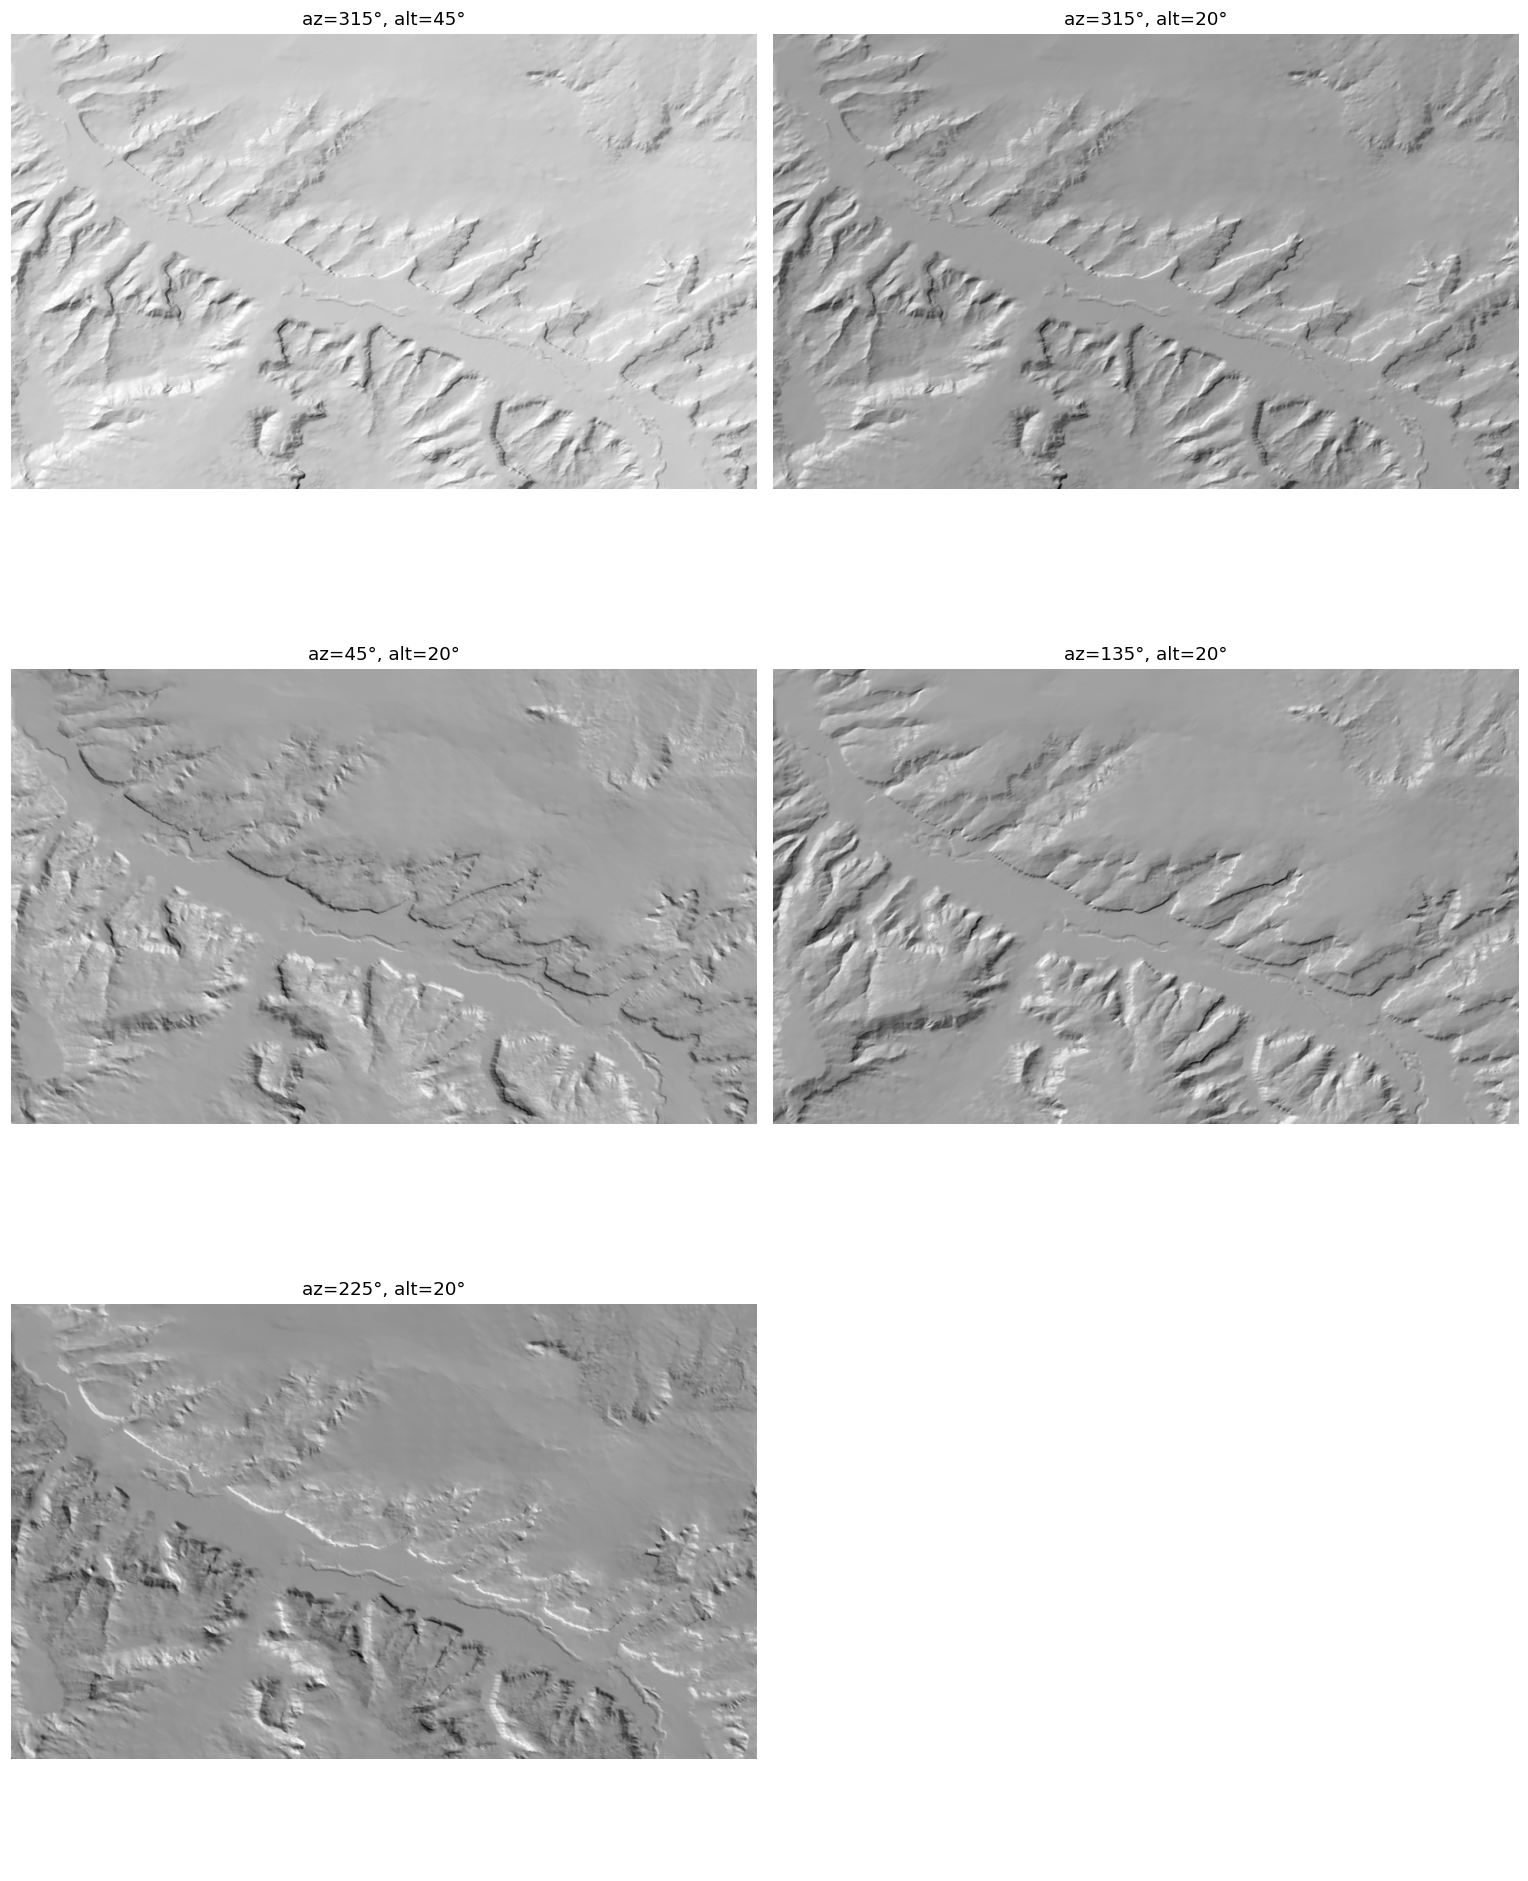

In [20]:
shades = []
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.ravel()

for i, p in enumerate(HILLSHADE_PARAMS):
    hs = hillshade(dem_filled, xres, yres, p["azimuth"], p["altitude"])
    shades.append(hs)
    tag = f"az{p['azimuth']}_alt{p['altitude']}"
    save_geotiff(OUT_DIR / f"hillshade_{tag}.tif", hs, profile)
    axes[i].imshow(hs, cmap="gray")
    axes[i].set_title(f"az={p['azimuth']}°, alt={p['altitude']}°")
    axes[i].axis("off")

axes[-1].axis("off")  # unused subplot
plt.tight_layout()
plt.savefig(OUT_DIR / "hillshade_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Multidirectional composite (the road-hunting layer)

Mean of the four low-angle shades. Sunken linear features survive the averaging; directional noise cancels. This is the layer to pan around in — or open the GeoTIFF in QGIS for proper zoom/contrast control.

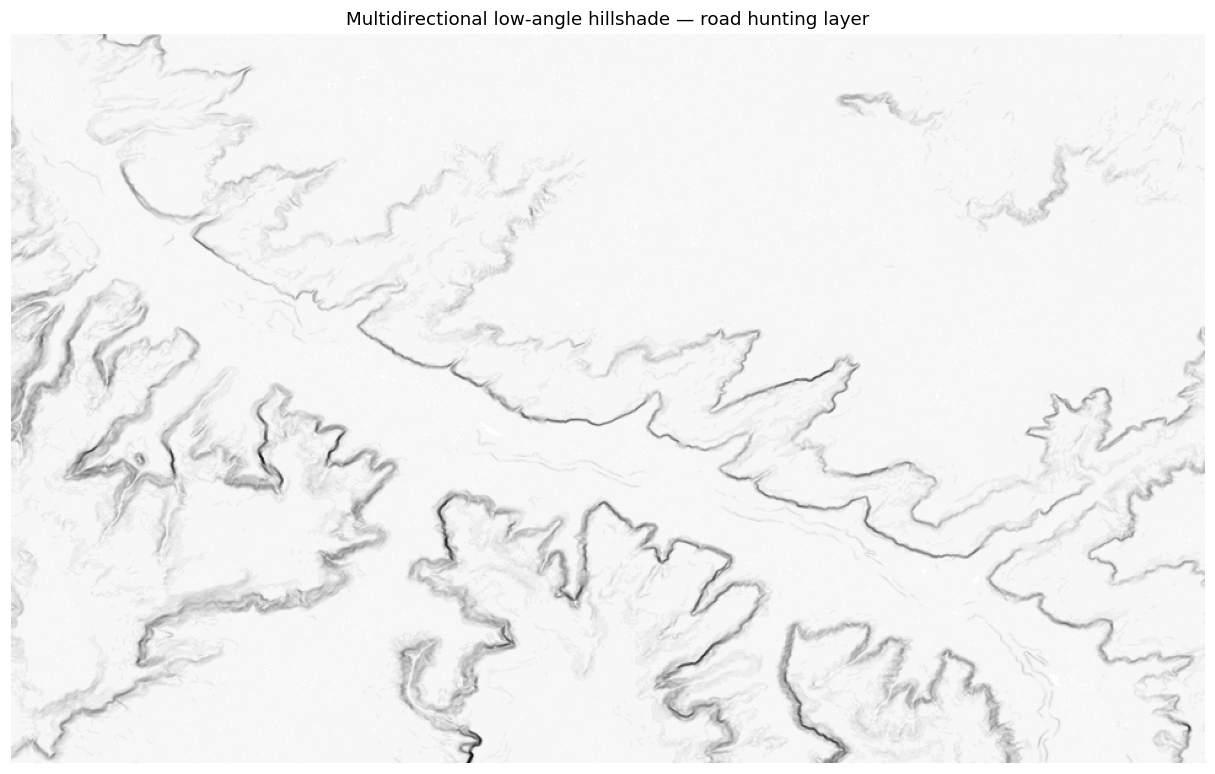

In [21]:
multi = np.mean(np.stack(shades[1:]), axis=0).astype(np.uint8)
save_geotiff(OUT_DIR / "hillshade_multidirectional.tif", multi, profile)

plt.figure(figsize=(14, 11))
plt.imshow(multi, cmap="gray")
plt.title("Multidirectional low-angle hillshade — road hunting layer")
plt.axis("off")
plt.savefig(OUT_DIR / "hillshade_multidirectional.png", dpi=200, bbox_inches="tight")
plt.show()

## 7 · Validation checklist

- [ ] Road segments visible north of Pueblo Bonito toward **Pueblo Alto**?
- [ ] Anything at the **Jackson Stairway** area?
- [ ] Do features appear/disappear as azimuth changes (real relief) rather than staying fixed (image artifact)?

If yes → pipeline validated. Everything in `output/` is georeferenced, so drag the `.tif` files into QGIS to overlay Weiner's published road maps.

**Next step (the actual priority):** reuse sections 1–3 with a North Carolina AOI (sound-side Roanoke Island / Beaufort inland), swap sections 4–6 for an elevation threshold (`dem > 15–20 ft`), and intersect the result with NC OneMap parcel polygons to get a candidate-parcel list.